# Distorted Visual Sequence Pattern Recognition using Deep Learning

**Author:** Saanvi Malik  
**Platform:** Kaggle  
**Task:** OCR — Sequence recognition from noisy grayscale images  
**Evaluation Metric:** Character Error Rate (CER)

## Abstract

In this project, I developed a deep learning-based OCR system for recognizing distorted alphanumeric text sequences from grayscale images. The dataset contains images with various types of distortions, including background noise, overlapping characters, blur, occlusion, shape deformation, and irregular spacing, which make the recognition task significantly more challenging than standard OCR problems.

The main objective was to build a model that could accurately recover the original character sequence despite these visual distortions. To achieve this, I experimented with different architectures and finally adopted a CRNN-inspired approach that combines convolutional feature extraction, sequence modeling, and attention mechanisms.

### Model Overview

The final architecture consists of four main components:

| Stage | Component                 | Purpose                                                                               |
| ----- | ------------------------- | ------------------------------------------------------------------------------------- |
| 1     | Custom CNN Backbone       | Extract visual features while preserving horizontal information                       |
| 2     | Bidirectional LSTM        | Model contextual dependencies between character positions                             |
| 3     | Multi-Head Self-Attention | Emphasize relevant features and improve robustness to overlap and occlusion           |
| 4     | CTC Decoder               | Generate variable-length text predictions without requiring character-level alignment |

### Results

The final model achieved strong performance on the validation set:

| Metric                 | Value      |
| ---------------------- | ---------- |
| Best Validation CER    | **0.0001** |
| Best Sequence Accuracy | **99.95%** |

These results indicate that the model is able to reliably reconstruct text sequences even under severe visual distortions.


## 1. Environment Setup and Imports

All required libraries are installed and imported here. A global random seed (`SEED=42`) is set across Python, NumPy, and PyTorch to ensure reproducibility.


In [1]:
import os
import random
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import cv2
import editdistance

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models
import time

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Exploratory Data Analysis (EDA)

Before building the OCR model, we analyze the dataset to understand its structure and characteristics. The EDA goals are:

- Examine the number of training samples and unique labels.
- Understand the **label length distribution** to guide CTC configuration.
- Identify the complete **character vocabulary** for tokenizer construction.
- Analyze **character frequencies** to assess class balance.
- Visually inspect distorted images to understand the nature of corruptions.
- Verify **image dimensions** for consistent preprocessing and batching.

These observations directly influence vocabulary construction, CTC decoding, image preprocessing strategy, and the choice of sequence modeling components.


In [2]:
TRAIN_IMG_DIR = "/kaggle/input/datasets/saanvimalik/distorted-ocr-dataset/cig_ps/train_images"
TEST_IMG_DIR = "/kaggle/input/datasets/saanvimalik/distorted-ocr-dataset/cig_ps/test_images"
TRAIN_CSV_PATH = "/kaggle/input/datasets/saanvimalik/distorted-ocr-dataset/cig_ps/train-labels.csv"

In [3]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
train_df.head()

,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [4]:
train_df = train_df.drop(columns=["Unnamed: 0"])
train_df.columns = ["image", "label"]

train_df["label"] = train_df["label"].astype(str)
train_df["label_len"] = train_df["label"].str.len()

print(f"Training Samples : {len(train_df):,}")
print(f"Unique Labels : {train_df['label'].nunique():,}")

display(train_df.head())

Training Samples : 20,000
Unique Labels : 19,999


,image,label,label_len
0,train-0.png,BU522X,6
1,train-1.png,XQ8NE2,6
2,train-2.png,DTZD3E,6
3,train-3.png,SM424H,6
4,train-4.png,6YVTQR,6


In [5]:
print("---Label Length Statistics---")
display(train_df["label_len"].describe())

all_chars = sorted(set("".join(train_df["label"])))

print(f"\nVocabulary Size: {len(all_chars)}")
print(f"Characters: {all_chars}")

char_freq = Counter("".join(train_df["label"]))

print("\nTop 20 Most Frequent Characters")
print(char_freq.most_common(20))

---Label Length Statistics---


count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000
Name: label_len, dtype: float64


Vocabulary Size: 38
Characters: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']

Top 20 Most Frequent Characters
[('7', 3989), ('E', 3966), ('X', 3956), ('G', 3942), ('Y', 3936), ('2', 3926), ('M', 3926), ('W', 3916), ('F', 3913), ('N', 3904), ('S', 3889), ('J', 3886), ('4', 3884), ('R', 3883), ('D', 3880), ('Q', 3873), ('C', 3861), ('Z', 3860), ('H', 3845), ('6', 3842)]


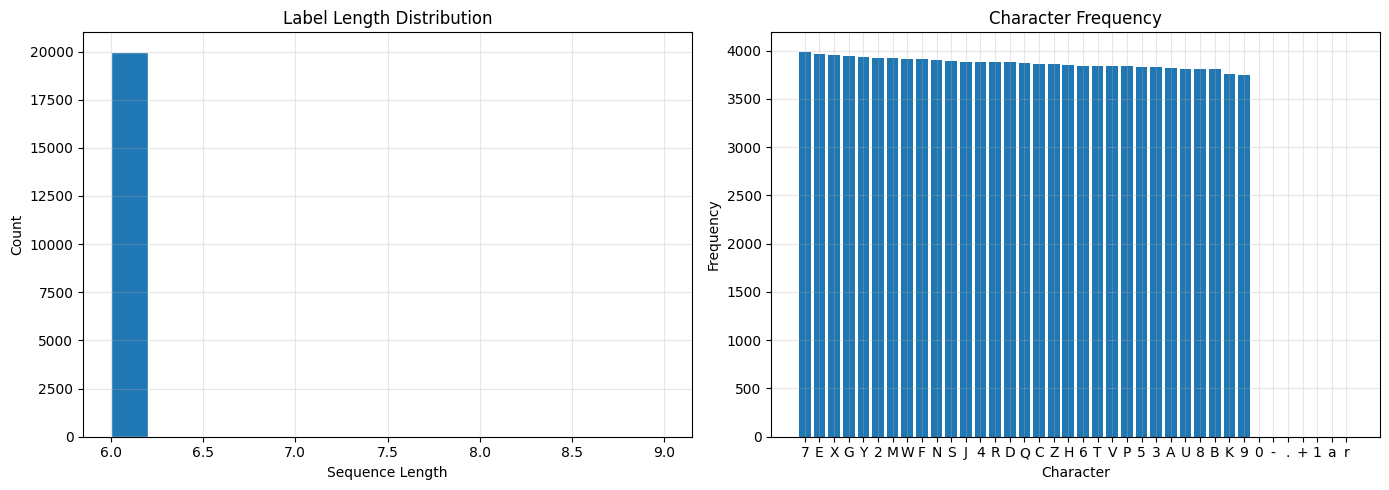

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label lengths
axes[0].hist(train_df["label_len"],bins=15,edgecolor="white")
axes[0].set_title("Label Length Distribution")
axes[0].set_xlabel("Sequence Length")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

# Character frequencies
chars, freqs = zip(*sorted(char_freq.items(),key=lambda x: x[1],reverse=True))
axes[1].bar(chars, freqs)
axes[1].set_title("Character Frequency")
axes[1].set_xlabel("Character")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations**

* The dataset contains a fixed vocabulary of characters that will be used to construct the OCR tokenizer.
* Character frequencies are relatively balanced, which reduces the risk of severe class imbalance during training.
* Sequence lengths are mostly around 6, making CTC-based sequence prediction well suited for this task.
* Since the labels are character sequences rather than independent classes, the problem is formulated as sequence recognition instead of image classification.
* The vocabulary size directly determines the output dimension of the final classification layer.


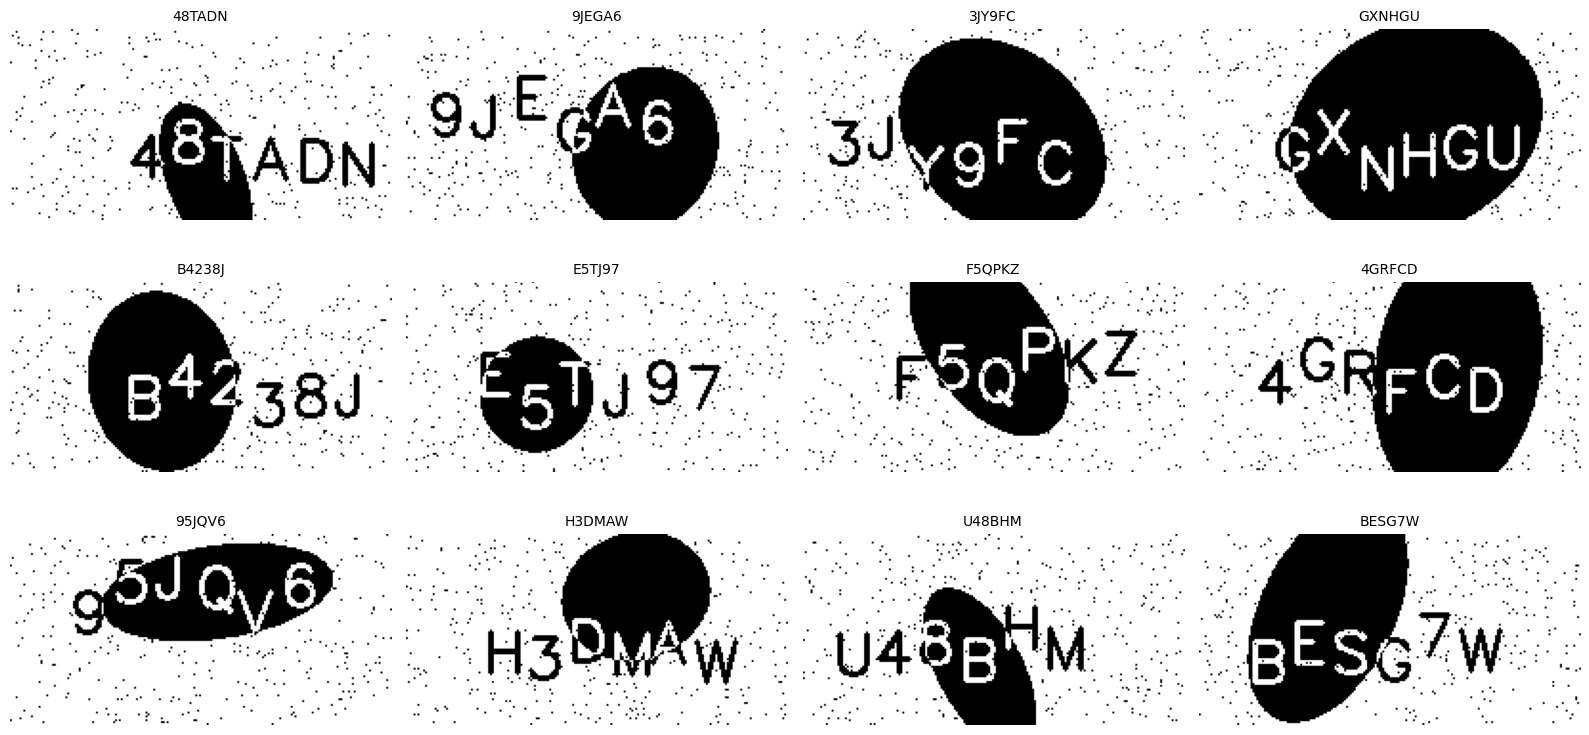

In [7]:
def show_sample_images(df, image_dir, n=12):
    sample_df = df.sample(n, random_state=SEED)
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows,cols,figsize=(16, 8))

    for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
        img_path = os.path.join(image_dir,row["image"])
        image = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

        ax.imshow(image, cmap="gray")
        ax.set_title(row["label"], fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(train_df,TRAIN_IMG_DIR)

**Visual Inspection**

The training images contain several distortions that make character recognition challenging:

* Background noise
* Character overlap
* Blur and visual artifacts
* Irregular spacing
* Shape deformation
* Partial occlusion


In [8]:
heights = []
widths = []
for image_name in train_df["image"].head(500):
    image_path = os.path.join(TRAIN_IMG_DIR,image_name)
    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

    if image is not None:
        h, w = image.shape
        heights.append(h)
        widths.append(w)

print("---Image Dimensions---")

print(
    f"Height -> min: {min(heights)}, "
    f"max: {max(heights)}, "
    f"mean: {np.mean(heights):.1f}")

print(
    f"Width  -> min: {min(widths)}, "
    f"max: {max(widths)}, "
    f"mean: {np.mean(widths):.1f}")

---Image Dimensions---
Height -> min: 100, max: 100, mean: 100.0
Width  -> min: 200, max: 200, mean: 200.0


**Impact on Model Design**

The EDA findings influence the final architecture in several ways:

* Grayscale images allow the use of a lightweight CNN backbone.
* Consistent image dimensions simplify preprocessing and batching.
* Short text sequences make CTC decoding efficient.
* Distorted and overlapping characters motivate the use of Bidirectional LSTM layers for contextual understanding.
* The attention module is introduced to help the model focus on informative regions when characters are partially occluded or visually corrupted.

These observations support the choice of a CNN → BiLSTM → Multi-Head Attention → CTC architecture for robust sequence recognition.


In [9]:
print(train_df["label_len"].value_counts().sort_index())

label_len
6    19998
8        1
9        1
Name: count, dtype: int64


## 3. Configuration and Vocabulary


### Global Configuration

All hyperparameters are centralized in a `CFG` class to make experimentation and reproducibility straightforward.

| Parameter | Value | Rationale |
| --- | --- | --- |
| `IMG_HEIGHT` | 100 | Matches the native height of training images; avoids distortion from resizing |
| `IMG_WIDTH` | 200 | Matches native width; preserves horizontal character spacing |
| `HIDDEN_SIZE` | 256 | Balances capacity and training speed for a BiLSTM on short sequences |
| `NUM_LSTM_LAYERS` | 2 | Two stacked BiLSTM layers capture both low and high-level sequential patterns |
| `DROPOUT` | 0.3 | Applied within LSTM to regularize sequential representations |
| `ATTN_HEADS` | 8 | Standard for `embed_dim=512`; each head attends to 64-dim subspaces |
| `BATCH_SIZE` | 64 | Fits comfortably in GPU memory; provides stable CTC gradient estimates |
| `EPOCHS` | 80 | Upper bound; early stopping (patience=10) typically halts training earlier |
| `LEARNING_RATE` | 3e-4 | AdamW default; works well with cosine annealing |
| `WEIGHT_DECAY` | 1e-4 | L2 regularization to reduce overfitting |
| `VAL_SPLIT` | 0.10 | 10% held out for validation; sufficient for stable CER estimates |
| `LR_MIN` | 1e-6 | Floor for cosine annealing; prevents learning rate collapsing to zero |

### Vocabulary and CTC Tokenizer

CTC requires a fixed vocabulary mapping characters to integer indices. **Index 0 is reserved as the CTC blank token** — it serves as a separator and is removed during decoding. All other characters are assigned indices starting from 1.

The `Vocabulary` class provides:
- `encode(text)` — converts a label string to a list of integer indices for CTC training.
- `decode(indices)` — converts model output indices back to a string, collapsing CTC duplicates and removing blanks.


In [10]:
class CFG:
    IMG_HEIGHT = 100
    IMG_WIDTH = 200

    HIDDEN_SIZE = 256
    NUM_LSTM_LAYERS = 2
    DROPOUT = 0.3

    ATTN_HEADS = 8
    
    BATCH_SIZE = 64
    EPOCHS = 80

    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 1e-4

    VAL_SPLIT = 0.10

    NUM_WORKERS = 4

    LR_MIN = 1e-6

    CHECKPOINT_DIR = "/kaggle/working/checkpoints"
    SUBMISSION_DIR = "/kaggle/working/submissions"

os.makedirs(CFG.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CFG.SUBMISSION_DIR, exist_ok=True)

In [11]:
class Vocabulary:
    BLANK_IDX = 0
    def __init__(self, labels):
        chars = sorted(set("".join(labels)))
        self.char2idx = {char: idx + 1 for idx, char in enumerate(chars)}
        self.idx2char = {idx: char for char, idx in self.char2idx.items()}

    @property
    def vocab_size(self):
        return len(self.char2idx) + 1

    def encode(self, text):
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def decode(self, indices, remove_duplicates=True):
        if remove_duplicates:
            # Collapse repeated indices (CTC rule)
            indices = [v for i, v in enumerate(indices)
                       if i == 0 or v != indices[i - 1]]
        # Remove blank tokens
        chars = [self.idx2char[i] for i in indices
                 if i != self.BLANK_IDX and i in self.idx2char]
        return ''.join(chars)

In [12]:
VOCAB = Vocabulary(train_df["label"].tolist())
print(f"Vocabulary Size: "f"{VOCAB.vocab_size}")
print(f"Characters: "f"{list(VOCAB.char2idx.keys())}")

Vocabulary Size: 39
Characters: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


In [13]:
sample_text = train_df["label"].iloc[0]
encoded = VOCAB.encode(sample_text)
decoded = VOCAB.decode(encoded, remove_duplicates=False)

print(f"Original : {sample_text}")
print(f"Encoded  : {encoded}")
print(f"Decoded  : {decoded}")
assert sample_text==decoded

Original : BU522X
Encoded  : [15, 31, 9, 6, 6, 34]
Decoded  : BU522X


In [14]:
NUM_CLASSES = VOCAB.vocab_size
print(f"Number of output classes: "f"{NUM_CLASSES}")

Number of output classes: 39


## 4. Image Preprocessing and Data Augmentation

The model must generalize to distortions it has never seen at test time. To achieve this, we apply a rich set of augmentations during **training only**. Validation and test images receive only normalization, ensuring that evaluation reflects true model performance on unmodified images.


In [15]:
def get_train_transforms():
    return A.Compose([
        # Noise
        A.GaussNoise(std_range=(0.02, 0.08), p=0.4),

        # Blur
        A.OneOf([A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=5, p=1.0)], p=0.3),
        
        # Geometric Distortion
        A.OneOf([A.GridDistortion(p=1.0),
                A.ElasticTransform(p=1.0)], p=0.3),

        # Position Variation
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.05,
            rotate_limit=3,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.4
        ),

        # Occlusion
        A.CoarseDropout(
            num_holes_range=(1, 6),
            hole_height_range=(0.02, 0.06),
            hole_width_range=(0.02, 0.08),
            fill=0,
            p=0.3
        ),

        # Contrast
        A.OneOf([A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15,p=1.0),
                A.RandomGamma(gamma_limit=(80, 120), p=1.0)], p=0.3),

        # Normalize
        A.Normalize(mean=[0.5], std=[0.5]),

        ToTensorV2()
    ])

In [16]:
def get_val_transforms():
    return A.Compose([A.Normalize(mean=[0.5], std=[0.5]), ToTensorV2()])

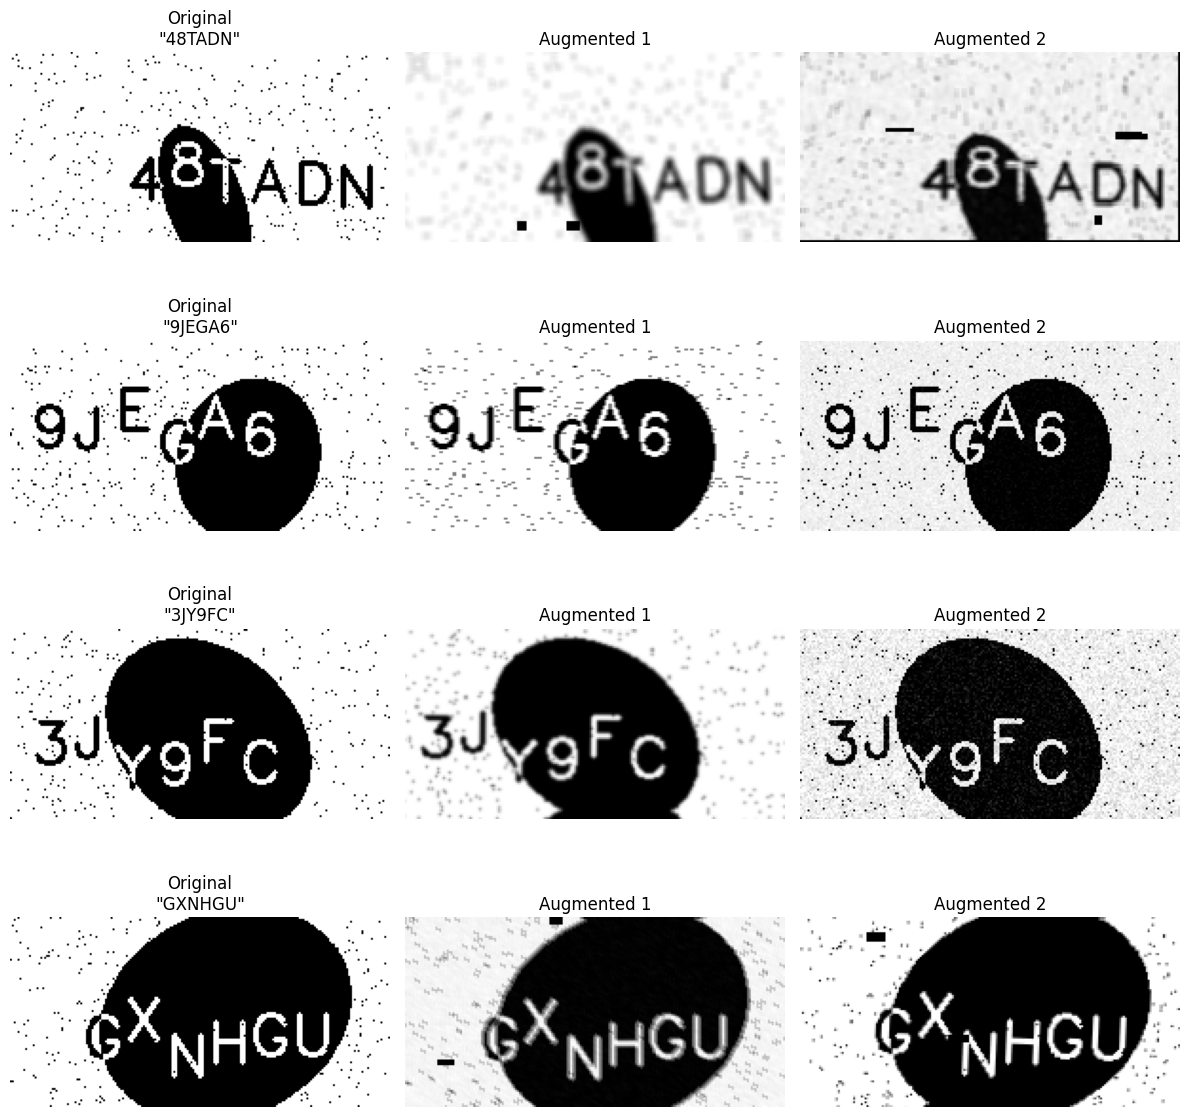

In [18]:
def visualize_augmentations(df, image_dir, n=4):
    transform = get_train_transforms()
    sample_df = df.sample(n, random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))
    for i in range(n):
        image_path = os.path.join(image_dir, sample_df.loc[i, "image"])
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        label = sample_df.loc[i, "label"]
        axes[i, 0].imshow(image, cmap="gray")

        axes[i, 0].set_title(f'Original\n"{label}"')
        axes[i, 0].axis("off")
        
        for j in [1, 2]:
            aug_img = transform(image=image)["image"]
            axes[i, j].imshow(aug_img.squeeze().numpy(), cmap="gray")
            axes[i, j].set_title(f"Augmented {j}")
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

visualize_augmentations(train_df, TRAIN_IMG_DIR)

### Why These Augmentations?

Each augmentation targets a specific challenge present in the dataset:

| Augmentation                | Purpose                                           |
| --------------------------- | ------------------------------------------------- |
| Gaussian Noise              | Simulates noisy backgrounds                       |
| Gaussian Blur / Motion Blur | Simulates image artifacts and blur                |
| Grid Distortion             | Simulates warped characters                       |
| Elastic Transform           | Simulates shape deformation                       |
| ShiftScaleRotate            | Simulates alignment variations                    |
| Coarse Dropout              | Simulates occlusion and missing character regions |
| Brightness / Gamma          | Simulates contrast variation                      |

These augmentations encourage the model to learn robust character representations instead of memorizing specific visual patterns. This is particularly important when using an attention-enhanced OCR architecture, where the attention mechanism must learn to focus on informative character regions despite distortions.


## 5. Dataset and Dataloader

The dataset class is responsible for:

* Loading grayscale OCR images.
* Applying preprocessing and augmentation.
* Encoding text labels into integer sequences.
* Returning samples in a format compatible with CTC loss.

A custom collate function is used which concatenates all target sequences into a single tensor and stores the length of each sequence, which is the format expected by PyTorch's CTC loss implementation.

In [19]:
class OCRDataset(Dataset):
    def __init__(self, df, image_dir, vocab, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.vocab = vocab
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir,row["image"])
        image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")

        if self.transform:image = self.transform(image=image)["image"]

        if self.is_test:
            return image, row["image"]

        label = torch.tensor(self.vocab.encode(row["label"]),dtype=torch.long) 

        return image, label, row["label"]

In [20]:
def collate_fn(batch):
    images, labels, raw_labels = zip(*batch)
    images = torch.stack(images)
    target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
    targets = torch.cat(labels)

    return (images, targets, target_lengths, raw_labels)

In [21]:
def collate_fn_test(batch):
    images, filenames = zip(*batch)

    return (torch.stack(images), list(filenames))

In [22]:
train_data, val_data = train_test_split(
    train_df,
    test_size=CFG.VAL_SPLIT,
    random_state=SEED,
    shuffle=True
)

train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print(f"Train Samples : {len(train_data):,}")
print(f"Val Samples   : {len(val_data):,}")

Train Samples : 18,000
Val Samples   : 2,000


In [23]:
train_dataset = OCRDataset(train_data, TRAIN_IMG_DIR, VOCAB, transform=get_train_transforms())
val_dataset = OCRDataset(val_data, TRAIN_IMG_DIR, VOCAB, transform=get_val_transforms())

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn
)

In [25]:
imgs, targets, target_lens, raw_labels = next(iter(train_loader))
print(f"Images Shape: {imgs.shape}")
print(f"Targets Shape: {targets.shape}")
print(f"Target Lengths: {target_lens.shape}")
print(f"Sample Labels: {list(raw_labels[:5])}")

Images Shape: torch.Size([64, 1, 100, 200])
Targets Shape: torch.Size([384])
Target Lengths: torch.Size([64])
Sample Labels: ['V4XJ9U', 'X9GMDW', 'ZR23RG', 'DMH2EB', 'YPDF8U']


In [26]:
print(f"Image dtype: {imgs.dtype}")
print(f"Image min: {imgs.min():.3f}")
print(f"Image max: {imgs.max():.3f}")

Image dtype: torch.float32
Image min: -1.000
Image max: 1.000


## 6. OCR Model Architecture

The final model follows a **CNN → BiLSTM → Multi-Head Attention → CTC** pipeline, combining visual feature extraction, sequence modeling, and attention-based context learning.

### Design Choices

**Custom CNN Backbone** - A ResNet-34 backbone was initially tested, but its aggressive downsampling reduced the feature map width to only 7 timesteps, which led to CTC alignment issues and caused systematic decoding failures for repeated characters. To preserve horizontal information, a custom CNN with height-only pooling (`MaxPool2d((2,1))`) was used, producing approximately 50 timesteps and significantly improving decoding performance.

**AdaptiveAvgPool + Sequence Conversion** - The 2D feature map `(B, C, H, W)` is collapsed to `(B, C, W)` using adaptive average pooling across height, then transposed to `(B, W, C)` to form a time-step sequence where each column of the feature map becomes one timestep.

**BiLSTM** - A two-layer Bidirectional LSTM models dependencies between neighboring characters in both directions, helping the network understand the sequential structure of the text.

**Multi-Head Self-Attention** - Self-attention is applied after the BiLSTM, allowing each timestep to access information from the entire sequence. This improves robustness to overlapping characters, occlusion, and other distortions.

**CTC Output Layer** - A linear layer projects each timestep to character logits, followed by log-softmax and CTC decoding to generate the final text prediction without requiring explicit character-level alignment.


In [27]:
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d((2,1)),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d((2,1))
        )

    def forward(self, x):
        return self.features(x)

In [28]:
class OCRModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.cnn = CNNBackbone()
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=CFG.HIDDEN_SIZE,
            num_layers=CFG.NUM_LSTM_LAYERS,
            bidirectional=True,
            batch_first=True,
            dropout=CFG.DROPOUT
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=CFG.HIDDEN_SIZE * 2,
            num_heads=CFG.ATTN_HEADS,
            dropout=0.1,
            batch_first=True
        )
        self.classifier = nn.Linear(CFG.HIDDEN_SIZE * 2, vocab_size)

    def forward(self, x):
        x = self.cnn(x)
        x = self.pool(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)

        x = lstm_out + attn_out
        logits = self.classifier(x)
        log_probs = torch.log_softmax(logits, dim=-1)

        return log_probs.permute(1, 0, 2)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [29]:
model = OCRModel(vocab_size=VOCAB.vocab_size).to(DEVICE)
print(model)
print(f"\nTrainable Parameters: "f"{model.count_parameters():,}")

OCRModel(
  (cnn): CNNBackbone(
    (features): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): ReLU()
      (14): M

In [30]:
model.eval()
with torch.no_grad():
    dummy = torch.randn(4,1, CFG.IMG_HEIGHT,CFG.IMG_WIDTH).to(DEVICE)
    output = model(dummy)

print(f"Input Shape  : {dummy.shape}")
print(f"Output Shape : {output.shape}")
print(f"Time Steps T : {output.shape[0]}")

Input Shape  : torch.Size([4, 1, 100, 200])
Output Shape : torch.Size([50, 4, 39])
Time Steps T : 50


## 7. CTC Loss and Decoding

A key challenge in OCR is that the exact alignment between image features and characters is usually unknown. To address this, the model uses **Connectionist Temporal Classification (CTC)**, which allows training directly from image-text pairs without requiring character-level annotations.

### CTC Loss

During training, the model outputs character probabilities for each timestep, and `nn.CTCLoss` computes the loss by considering all valid alignments that could produce the target text. This makes CTC particularly well-suited for sequence recognition tasks such as OCR.

The implementation uses `zero_infinity=True` to avoid numerical issues in rare edge cases where the loss can become infinite.

### Greedy Decoding

During inference, predictions are generated using greedy decoding:

1. Select the most probable character at each timestep.
2. Merge consecutive duplicate predictions.
3. Remove blank tokens.
4. Convert indices back to text.

This approach is fast and works well in practice, although more advanced methods such as beam search could potentially provide additional improvements.

### Evaluation Metric

Model performance is evaluated using **Character Error Rate (CER)**, calculated as the Levenshtein distance between the predicted and target text divided by the target length. Lower CER values indicate better recognition accuracy, while a CER of 0 corresponds to a perfect prediction.


In [31]:
ctc_loss_fn = nn.CTCLoss(blank=VOCAB.BLANK_IDX, reduction="mean", zero_infinity=True)

In [32]:
def compute_ctc_loss(log_probs, targets, target_lengths):
    T, B, _ = log_probs.shape
    input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long, device=targets.device)

    return ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)

In [33]:
def greedy_decode(log_probs, vocab):
    predictions = []
    pred_indices = (log_probs.argmax(dim=2).cpu().numpy())

    for b in range(pred_indices.shape[1]):
        text = vocab.decode(pred_indices[:, b].tolist())
        predictions.append(text)

    return predictions

In [34]:
def compute_cer(predictions, targets):
    scores = []
    for pred, target in zip(predictions, targets):
        distance = editdistance.eval(pred, target)
        scores.append(distance / len(target))

    return np.mean(scores)

In [35]:
assert compute_cer(["AXU323"], ["AXU323"]) == 0.0
assert compute_cer(["AXU323"], ["AXU000"]) > 0.0
assert compute_cer([""], ["AXU323"]) == 1.0

print("CER verified")

CER verified


In [36]:
def sequence_accuracy(predictions, targets):
    correct = sum(p == t for p, t in zip(predictions, targets))

    return correct / len(targets)

## 8. Training Strategy

The model is trained using **AdamW**, which provides effective optimization while applying weight decay separately from the gradient update. A **cosine annealing** learning rate schedule gradually reduces the learning rate throughout training, helping the model converge more smoothly.

To improve training efficiency, **mixed precision training (AMP)** is enabled using PyTorch's `autocast` and `GradScaler`. This reduces GPU memory usage and speeds up training without affecting model performance.

Since recurrent networks can be sensitive to large gradients, **gradient clipping** with a maximum norm of 5.0 is applied before each optimizer step. In addition, **early stopping** monitors validation CER and stops training when performance stops improving, while automatically saving the best-performing checkpoint.

### Regularization Techniques

| Technique               | Purpose                            |
| ----------------------- | ---------------------------------- |
| Weight Decay (1e-4)     | Reduces overfitting                |
| LSTM Dropout (0.3)      | Improves generalization            |
| Attention Dropout (0.1) | Regularizes attention weights      |
| Data Augmentation       | Improves robustness to distortions |
| Gradient Clipping (5.0) | Prevents unstable updates          |


In [37]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4, checkpoint_path="best_model.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = checkpoint_path
        self.best_score = None
        self.counter = 0

    def step(self, val_cer, model):
        if (self.best_score is None or val_cer < self.best_score - self.min_delta):
            self.best_score = val_cer
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            print(f"✓ Checkpoint Saved "f"(CER={val_cer:.4f})")

        else:
            self.counter += 1
            print(f" Early Stop Counter: "f"{self.counter}/{self.patience}")

        return self.counter >= self.patience

In [38]:
def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            log_probs = model(images)
            loss = compute_ctc_loss(log_probs, targets, target_lengths)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [39]:
@torch.no_grad()
def validate(model, loader, vocab, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    for images, targets, target_lengths, raw_labels in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        log_probs = model(images)

        loss = compute_ctc_loss(log_probs, targets, target_lengths)

        total_loss += loss.item()

        preds = greedy_decode(log_probs, vocab)

        all_preds.extend(preds)
        all_targets.extend(raw_labels)

    avg_loss = total_loss / len(loader)
    avg_cer = compute_cer(all_preds, all_targets)
    seq_acc = sequence_accuracy(all_preds, all_targets)
    
    idx = np.random.choice(len(all_preds), 10, replace=False)
    examples = [(all_preds[i], all_targets[i]) for i in idx]

    return (avg_loss, avg_cer, seq_acc, examples)

In [40]:
model = OCRModel(vocab_size=VOCAB.vocab_size).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=CFG.LEARNING_RATE, weight_decay=CFG.WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=CFG.LR_MIN)
scaler = torch.cuda.amp.GradScaler()

CHECKPOINT_PATH = os.path.join(CFG.CHECKPOINT_DIR, "best_attention_ctc.pt")

early_stop = EarlyStopping(patience=10, checkpoint_path=CHECKPOINT_PATH)

In [41]:
history = {"train_loss": [], "val_loss": [], "val_cer": [], "val_acc": [], "lr": []}
print(
    f"{'Epoch':>5}"
    f"{'Train':>12}"
    f"{'Val':>12}"
    f"{'CER':>10}"
    f"{'Acc':>10}"
    f"{'LR':>12}"
)
print('─' * 64)
for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_loss, val_cer, val_acc, examples = validate(model, val_loader, VOCAB, DEVICE)
    current_lr = scheduler.get_last_lr()[0]
    
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_cer"].append(val_cer)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.4f} | "
        f"Val {val_loss:.4f} | "
        f"CER {val_cer:.4f} | "
        f"Acc {val_acc:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{elapsed:.1f}s"
    )

    if epoch <= 3 or epoch % 5 == 0:
        print("\nSample predictions:")
        for pred, truth in examples[:4]:
            match = "✓" if pred == truth else "✗"
            print("{match} "f'"{pred}" -> "{truth}"')
        print()

    if early_stop.step(val_cer, model):
        print(f"\nEarly stopping at epoch {epoch}")
        break

Epoch       Train         Val       CER       Acc          LR
────────────────────────────────────────────────────────────────
Epoch 01 | Train 4.2497 | Val 3.6635 | CER 1.0000 | Acc 0.0000 | LR 3.00e-04 | 56.4s

Sample predictions:
{match} "" -> "HPU6J6"
{match} "" -> "BQAR8S"
{match} "" -> "XHFT9Q"
{match} "" -> "GCH36S"

✓ Checkpoint Saved (CER=1.0000)
Epoch 02 | Train 2.1638 | Val 0.2810 | CER 0.0779 | Acc 0.6170 | LR 3.00e-04 | 35.6s

Sample predictions:
{match} "KRMW4BF" -> "KRM4BF"
{match} "7RV9Q7" -> "7RV9Q7"
{match} "BC8J3P" -> "BG6J3P"
{match} "5UHYWS" -> "8UHYWS"

✓ Checkpoint Saved (CER=0.0779)
Epoch 03 | Train 0.1381 | Val 0.0119 | CER 0.0031 | Acc 0.9815 | LR 3.00e-04 | 37.2s

Sample predictions:
{match} "DQH39T" -> "DQH39T"
{match} "YRJFAD" -> "YRJFAD"
{match} "77MPXF" -> "77MPXF"
{match} "79B4U8" -> "79B4U8"

✓ Checkpoint Saved (CER=0.0031)
Epoch 04 | Train 0.0407 | Val 0.0085 | CER 0.0018 | Acc 0.9890 | LR 2.99e-04 | 36.0s
✓ Checkpoint Saved (CER=0.0018)
Epoch 05 | Tra

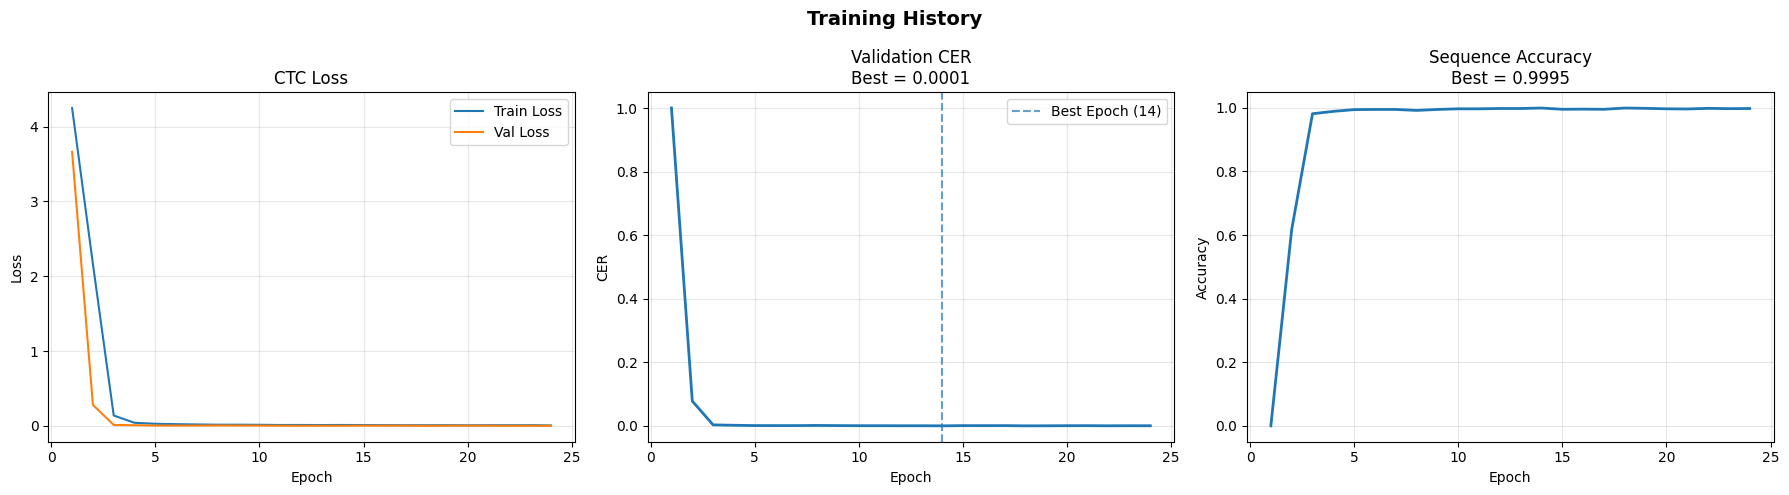

Best Validation CER: 0.0001
Best Epoch: 14
Best Sequence Acc: 0.9995


In [42]:
epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

# Loss Curves
axes[0].plot(x, history["train_loss"], label="Train Loss")
axes[0].plot(x, history["val_loss"], label="Val Loss")
axes[0].set_title("CTC Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# CER
best_epoch = np.argmin(history["val_cer"]) + 1
best_cer = min(history["val_cer"])
axes[1].plot(x, history["val_cer"], linewidth=2)
axes[1].axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best Epoch ({best_epoch})")
axes[1].set_title(f"Validation CER\nBest = {best_cer:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Sequence Accuracy
best_acc = max(history["val_acc"])
axes[2].plot(x, history["val_acc"], linewidth=2)
axes[2].set_title(f"Sequence Accuracy\nBest = {best_acc:.4f}")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best Validation CER: {best_cer:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Best Sequence Acc: {best_acc:.4f}")

## 9. Inference on Test Set

The best model checkpoint (lowest validation CER) saved during training is loaded for inference. Test images are passed through the same preprocessing pipeline as validation images (normalization only — no augmentation) to ensure consistent results.

Predictions are generated using greedy CTC decoding and saved as `submission.csv`.


In [43]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"Best Validation CER: {early_stop.best_score:.4f}")

Loaded checkpoint: /kaggle/working/checkpoints/best_attention_ctc.pt
Best Validation CER: 0.0001


In [44]:
test_files = sorted(os.listdir(TEST_IMG_DIR))
test_df = pd.DataFrame({"image": test_files})
print(f"Test Images: {len(test_df):,}")

Test Images: 5,000


In [45]:
test_dataset = OCRDataset(test_df, TEST_IMG_DIR, VOCAB, transform=get_val_transforms(), is_test=True)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn_test
)

In [46]:
@torch.no_grad()
def predict(model, loader, vocab, device):
    model.eval()
    predictions = {}
    for images, filenames in loader:
        images = images.to(device)
        log_probs = model(images)
        preds = greedy_decode(log_probs, vocab)

        for fname, pred in zip(filenames, preds):
            predictions[fname] = pred

    return predictions

In [48]:
predictions = predict(model, test_loader, VOCAB, DEVICE)
print(f"Generated predictions for {len(predictions)} images")

Generated predictions for 5000 images


In [49]:
for fname, pred in list(predictions.items())[:5]:
    print(f"{fname} → {pred}")

test-0.png → QVTQ8A
test-1.png → 7PSW9D
test-10.png → 7DUP98
test-100.png → 75Z4WT
test-1000.png → QAKZ7V


In [50]:
submission = pd.DataFrame({
    "image": test_files,
    "prediction": [predictions[f] for f in test_files]
})

In [51]:
submission["prediction"].str.len().value_counts()

prediction
6    4999
5       1
Name: count, dtype: int64

In [52]:
submission_path = os.path.join(CFG.SUBMISSION_DIR, f"submission.csv")
submission.to_csv(submission_path, index=False)
print(f"Submission saved: {submission_path}")

Submission saved: /kaggle/working/submissions/submission.csv


In [53]:
assert list(submission.columns) == ["image","prediction"]
assert submission["image"].is_unique
assert submission["prediction"].notna().all()
print("Submission validated")
print(f"Rows: {len(submission)}")

Submission validated
Rows: 5000


## 10. Error Analysis

Aggregate metrics like CER give a summary of model performance but do not explain *why* errors occur. This section performs a deeper analysis to identify systematic failure modes:

- **CER distribution** — Are errors concentrated in a few hard samples, or spread uniformly?
- **Sequence accuracy breakdown** — What fraction of predictions are fully correct vs. partially wrong?
- **Worst predictions** — What do high-CER failure cases look like?
- **Character confusion matrix** — Which specific character pairs are most commonly confused?

Understanding these patterns informs potential improvements such as targeted augmentation, focal loss weighting, or post-processing with a language model.


In [54]:
model.eval()
all_preds = []
all_truths = []
with torch.no_grad():
    for images, _, _, raw_labels in val_loader:
        images = images.to(DEVICE)
        log_probs = model(images)
        preds = greedy_decode(log_probs, VOCAB)
        
        all_preds.extend(preds)
        all_truths.extend(raw_labels)

In [55]:
results_df = pd.DataFrame({
    "truth": all_truths,
    "prediction": all_preds
})

results_df["cer"] = [editdistance.eval(pred, truth)/ len(truth)
    for pred, truth
    in zip(all_preds, all_truths)
]

results_df["correct"] = (results_df["cer"] == 0)

In [56]:
seq_acc = sequence_accuracy(all_preds, all_truths)
avg_cer = compute_cer(all_preds, all_truths)
print(f"Sequence Accuracy: {seq_acc:.4f}")
print(f"Mean CER: {avg_cer:.4f}")

Sequence Accuracy: 0.9995
Mean CER: 0.0001


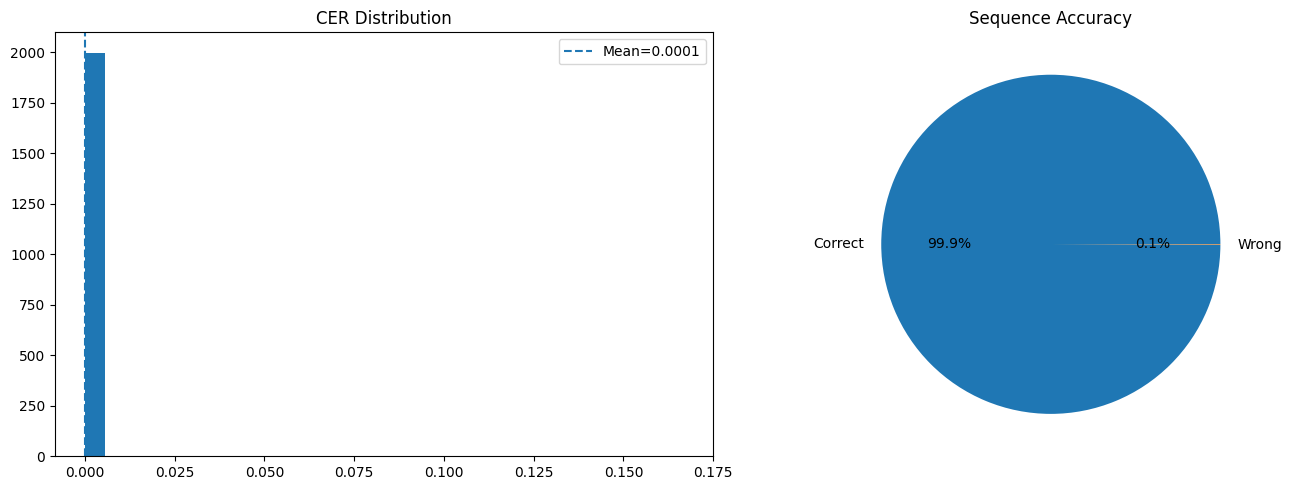

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CER Distribution
axes[0].hist(results_df["cer"], bins=30)
axes[0].axvline(avg_cer, linestyle="--", label=f"Mean={avg_cer:.4f}")
axes[0].set_title("CER Distribution")
axes[0].legend()

# Sequence Accuracy
axes[1].pie([results_df["correct"].sum(), (~results_df["correct"]).sum()], 
            labels=["Correct", "Wrong"], autopct="%1.1f%%")
axes[1].set_title("Sequence Accuracy")
plt.tight_layout()
plt.show()

In [58]:
worst = (results_df.query("cer>0").nlargest(10, "cer"))
display(worst[["truth", "prediction", "cer"]])

,truth,prediction,cer
507,HRQEW5,HPQEW5,0.166667


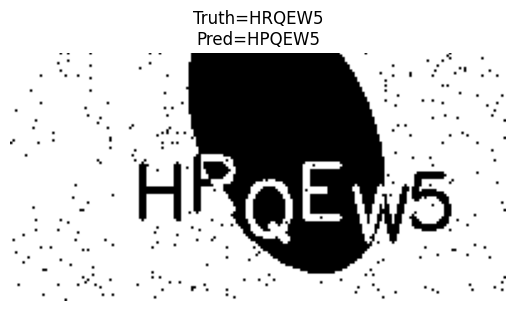

In [64]:
idx = 507
img_name = val_data.loc[idx, "image"]
img = cv2.imread(os.path.join(TRAIN_IMG_DIR, img_name), cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")
plt.title(f'Truth={results_df.loc[idx,"truth"]}\n'
    f'Pred={results_df.loc[idx,"prediction"]}'
)
plt.axis("off")
plt.show()

In [ ]:
worst_idx = worst.index.tolist()
fig, axes = plt.subplots(len(worst_idx), 1, figsize=(10, 3 * len(worst_idx)))
axes = np.atleast_1d(axes)

for ax, idx in zip(axes, worst_idx):
    image_name = val_data.loc[idx, "image"]
    image_path = os.path.join(TRAIN_IMG_DIR, image_name)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f'Truth: {results_df.loc[idx, "truth"]} | '
        f'Pred: {results_df.loc[idx, "prediction"]} | '
        f'CER: {results_df.loc[idx, "cer"]:.3f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [61]:
confusion = {}
for truth, pred in zip(all_truths, all_preds):
    if len(truth) != len(pred):
        continue
    for t, p in zip(truth, pred):
        if t != p:
            key = f"{t}→{p}"
            confusion[key] = (confusion.get(key, 0) + 1)

top_confusions = sorted(confusion.items(), key=lambda x: x[1], reverse=True)[:15]
print("Top Character Confusions\n")
for pair, count in top_confusions:
    print(f"{pair:10s} × {count}")

Top Character Confusions

R→P        × 1


The model achieves near-perfect character recognition despite heavy visual corruption in the input images. The key insight was preserving the horizontal (temporal) resolution of the feature map through height-only pooling, which allowed CTC to reliably align predictions with target sequences.